# Linear Regression on CABA Housing Prices

Implementation of three methods to solve the linear regression problem:
- Normal Equations
- Batch Gradient Descent  
- Stochastic Gradient Descent

We start with a simple univariate regression using `metros` as the 
only feature to predict `precio`.

## Dataset
Scraped from ZonaProp, cleaned and processed. 32,585 properties 
in Buenos Aires (CABA).

### Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Load data

In [4]:
df = pd.read_csv("data/zonaprop_clean.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (32585, 7)


,precio,expensas,metros,ambientes,banos,barrio,comuna
0,530000.0,770000,172.0,4.0,3.0,PALERMO,14
1,170000.0,0,73.0,4.0,1.0,VILLA CRESPO,15
2,120000.0,260000,54.0,3.0,1.0,RECOLETA,2
3,220000.0,380073,68.0,3.0,2.0,NUÑEZ,13
4,84100.0,110000,55.0,1.0,1.0,VILLA LURO,10


### Extract feature and target

In [6]:
X = df["metros"].values
y = df["precio"].values

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nX range: {X.min():.0f} - {X.max():.0f} m²")
print(f"y range: USD {y.min():,.0f} - USD {y.max():,.0f}")

X shape: (32585,)
y shape: (32585,)

X range: 25 - 500 m²
y range: USD 54,900 - USD 2,500,000


Before fitting any model, let's visualize the relationship between 
`metros` and `precio`.

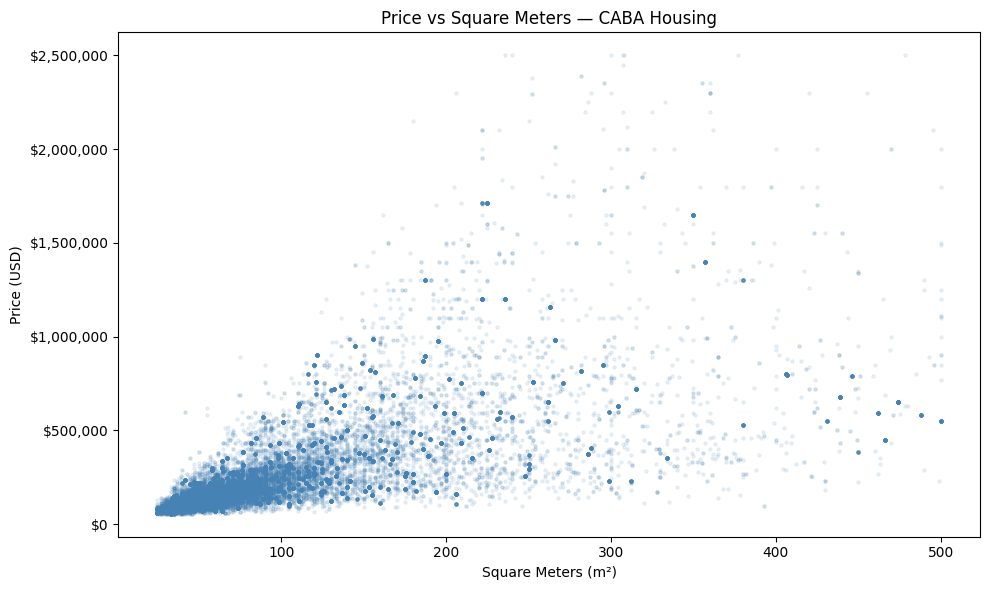

In [16]:
plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.1, s=5, color="steelblue")
plt.title("Price vs Square Meters — CABA Housing")
plt.xlabel("Square Meters (m²)")
plt.ylabel("Price (USD)")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:,.0f}"))
plt.tight_layout()
plt.show()

### Add bias term (column of ones)

This allows the model to learn an intercept $\theta_0$, so the regression 
line doesn't have to pass through the origin. Without it, 
the model would assume a property with 0 m² costs 
USD 0, which is unrealistic.

$$h_\theta(x) = \theta_0 + \theta_1 x$$
$$X_b = \begin{bmatrix} 1 & x^{(1)} \\ 1 & x^{(2)} \\ \vdots & \vdots \\ 1 & x^{(m)} \end{bmatrix}$$

In [7]:
X_b = np.column_stack([np.ones(len(X)), X])

print(f"X_b shape: {X_b.shape}")
print(f"\nFirst 5 rows of X_b:")
print(X_b[:5])

X_b shape: (32585, 2)

First 5 rows of X_b:
[[  1. 172.]
 [  1.  73.]
 [  1.  54.]
 [  1.  68.]
 [  1.  55.]]


### Train/Test Split

We split the dataset into 80% training and 20% test. The model learns 
from the training set and we evaluate performance on the test set,
data the model has never seen.

In [8]:
np.random.seed(42)
m = len(X_b)
indices = np.random.permutation(m)

train_size = int(0.8 * m)
train_idx = indices[:train_size]
test_idx  = indices[train_size:]

X_train, X_test = X_b[train_idx], X_b[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f"Train size: {len(X_train):,}")
print(f"Test size:  {len(X_test):,}")

Train size: 26,068
Test size:  6,517


### Cost Function

The cost function measures how well the model fits the data. 
We use the Mean Squared Error (MSE):

$$J(\theta) = \frac{1}{2m}\sum_{i=1}^{m}(h_\theta(x^{(i)}) - y^{(i)})^2$$

The $\frac{1}{2m}$ normalizes by the number of examples so the 
cost is comparable across different dataset sizes.

In [9]:
def cost_function(X, y, theta):
    m = len(y)
    predictions = X @ theta
    error = predictions - y
    return (1 / (2 * m)) * np.sum(error ** 2)

## 1. Normal Equations

The normal equations give us the exact solution to the linear regression
problem in one shot — no iterations needed:

$$\theta = (X^TX)^{-1}X^Ty$$

This is the closed-form solution we derived analytically in PS0.

In [17]:
def normal_equations(X, y):
    return np.linalg.inv(X.T @ X) @ X.T @ y

theta_ne = normal_equations(X_train, y_train)
print(f"theta_0 (intercept): USD {theta_ne[0]:,.2f}")
print(f"theta_1 (slope):     USD {theta_ne[1]:,.2f} per m²")

theta_0 (intercept): USD 49,600.35
theta_1 (slope):     USD 2,185.19 per m²


The model learns two parameters:
- **Intercept** $\theta_0 = 49,600$: the base price of a property 
  regardless of size.
- **Slope** $\theta_1 = 2,185$: each additional m² adds USD 2,185 
  to the price.

So the model predicts: $\text{price} = 49,600 + 2,185 \times \text{meters}$

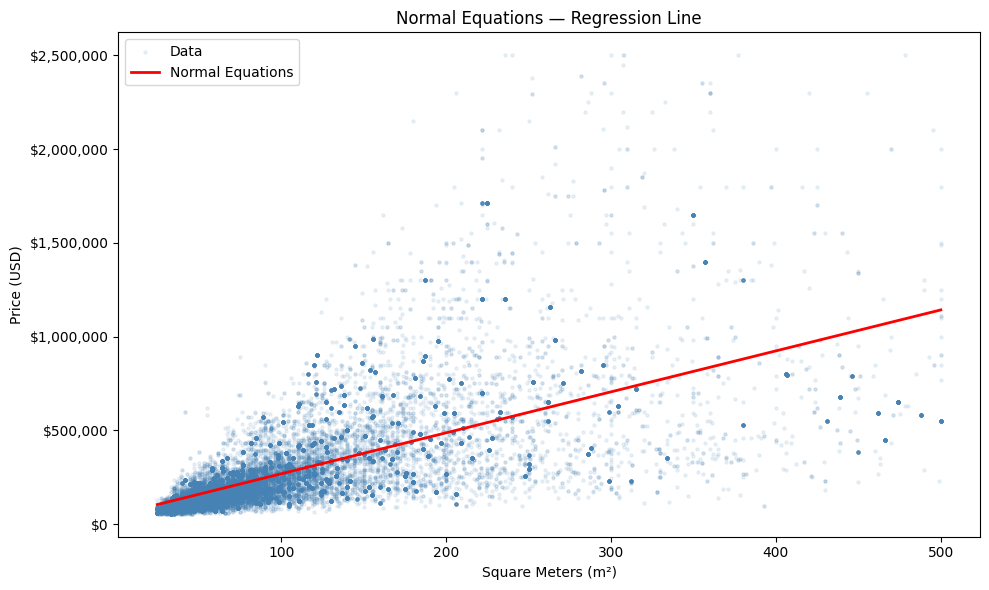

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))

# Scatter
ax.scatter(X, y, alpha=0.1, s=5, color="steelblue", label="Data")

# Regression line
x_line = np.linspace(X.min(), X.max(), 100)
y_line = theta_ne[0] + theta_ne[1] * x_line
ax.plot(x_line, y_line, color="red", linewidth=2, label="Normal Equations")

ax.set_title("Normal Equations — Regression Line")
ax.set_xlabel("Square Meters (m²)")
ax.set_ylabel("Price (USD)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:,.0f}"))
ax.legend()
plt.tight_layout()
plt.show()

#### Evaluate using cost function

In [ ]:
train_cost = cost_function(X_train, y_train, theta_ne)
test_cost = cost_function(X_test, y_test, theta_ne)

print(f"Train cost: {train_cost:,.2f}")
print(f"Test cost:  {test_cost:,.2f}")

Train cost: 18,119,288,602.71
Test cost:  16,932,954,636.59


#### Plotting cost function

In [20]:
# Grid of theta values around the optimal solution
theta0_vals = np.linspace(-100000, 200000, 100)
theta1_vals = np.linspace(0, 4000, 100)
J_vals = np.zeros((len(theta0_vals), len(theta1_vals)))

# Compute cost for each combination
for i, t0 in enumerate(theta0_vals):
    for j, t1 in enumerate(theta1_vals):
        theta = np.array([t0, t1])
        J_vals[i, j] = cost_function(X_train, y_train, theta)

T0, T1 = np.meshgrid(theta0_vals, theta1_vals)
J_grid = J_vals.T

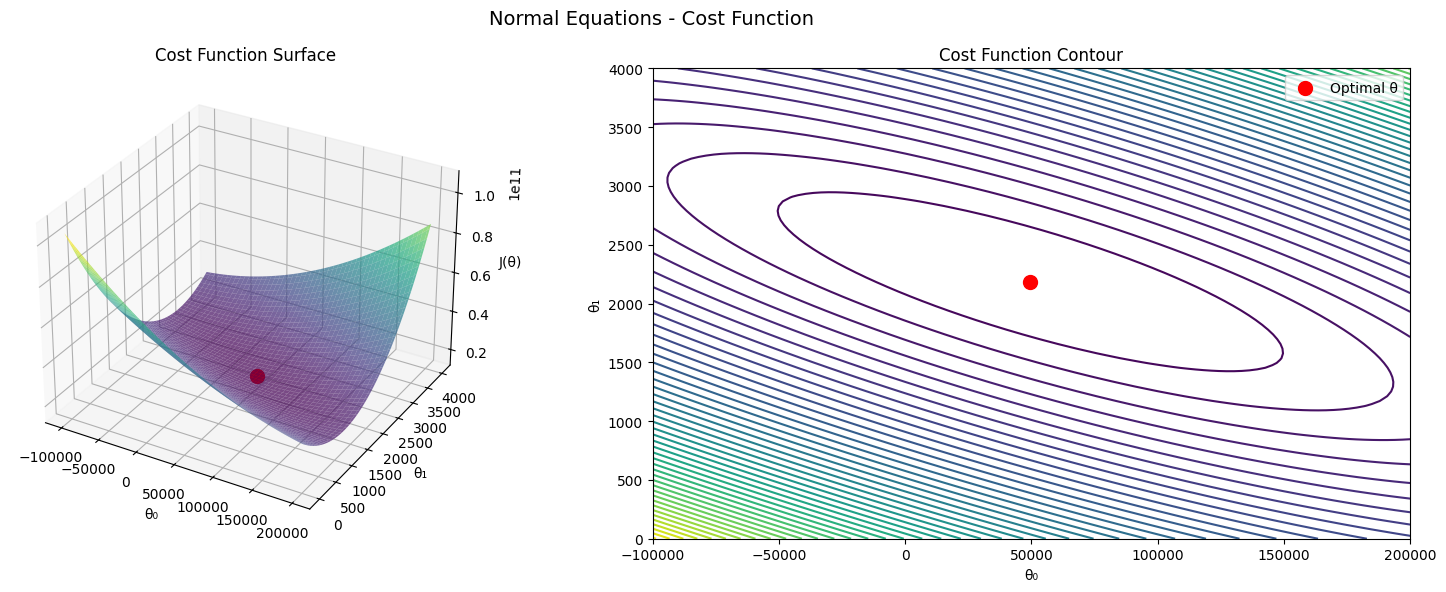

In [22]:
fig = plt.figure(figsize=(16, 6))

# 3D Surface
ax1 = fig.add_subplot(121, projection="3d")
ax1.plot_surface(T0, T1, J_grid, cmap="viridis", alpha=0.7)
ax1.scatter(theta_ne[0], theta_ne[1], 
            cost_function(X_train, y_train, theta_ne),
            color="red", s=100, zorder=5, label="Optimal θ")
ax1.set_xlabel("θ₀")
ax1.set_ylabel("θ₁")
ax1.set_zlabel("J(θ)")
ax1.set_title("Cost Function Surface")

# Contour plot
ax2 = fig.add_subplot(122)
ax2.contour(T0, T1, J_grid, levels=50, cmap="viridis")
ax2.scatter(theta_ne[0], theta_ne[1], 
            color="red", s=100, zorder=5, label="Optimal θ")
ax2.set_xlabel("θ₀")
ax2.set_ylabel("θ₁")
ax2.set_title("Cost Function Contour")
ax2.legend()

plt.suptitle("Normal Equations - Cost Function", fontsize=14)
plt.tight_layout()
plt.show()